# Group03_PRBD - GNN (GCN + GATv2) vs. Best CNN Baseline

**Dataset:** PRBD - Processed Rice Bangladesh Dataset (Mendeley Data)
**Group:** Group03 · CSE475 Machine Learning, Summer 2026
**Assigned track:** Track 3 - CNN + Attention

This notebook is an exploratory comparison, prepared ahead of Task 3, evaluating graph neural network (GNN) performance on this dataset alongside a strong CNN reference.

## Overview

Rice grain images are not naturally graph-structured, so applying a GNN requires first converting each image into a graph. This notebook uses the standard, literature-established approach:

1. **SLIC superpixel segmentation** breaks each image into ~70-90 visually coherent regions.
2. Each superpixel becomes a **graph node**, carrying colour, texture, and position features.
3. Spatially adjacent superpixels are connected by edges, forming a **Region Adjacency Graph (RAG)**.

Two GNN architectures are trained on the resulting graphs:

- **GCN** (Kipf & Welling, 2017) - neighbourhood-averaging convolution.
- **GATv2** (Brody et al., 2022) - learns a per-edge attention weight, so each node adaptively weighs which neighbours matter most (the graph analogue of the CBAM attention used in Task 2).

A **ResNet50 CNN baseline**, using the same recipe as Task 2, is retrained on the identical leakage-free split so all three models are compared fairly under one protocol.

## Methodology

- **Leakage-free split:** class-stratified 70/10/20 split from `Original_Images` only, fixed seed, reused identically across all models.
- **Train-only statistic fitting:** node-feature normalization is fit on training graphs only, then applied to validation/test.
- **5-fold stratified cross-validation** on the train+val pool for all three models - the test set is never touched during CV.
- **Regularization:** dropout, batch/graph normalization, weight decay, and early stopping on validation macro-F1 for every model.
- **Single honest test-set evaluation:** each model is refit once on the full train+val pool and evaluated exactly once on the held-out test set.

## Scope note

Per the project brief, the GNN bonus applies only to Track 1 (GNN) and Track 2 (GCN); Track 3 (our assigned track). This notebook is therefore supplementary exploration, only for comparison - Task 3 itself (CNN+CBAM ablation, CV, significance testing, Grad-CAM/LIME) proceeds separately.



## 1. Setup — Installs, Imports, Reproducibility

In [1]:
# torch / torchvision are already present on Kaggle GPU images.
# torch_geometric is the only extra package needed (works without the optional
# torch-scatter/torch-sparse compiled extras for the layers we use: GCNConv,
# GATv2Conv, global_mean_pool, global_max_pool all have native PyTorch fallbacks).
!pip install -q torch_geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.9 MB/s eta 0:00:0000:0100:01


In [2]:
import os, sys, time, json, random, pickle, warnings, math
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset

import torchvision
from torchvision import transforms, models

from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, GATv2Conv, global_mean_pool, global_max_pool, BatchNorm

from skimage.segmentation import slic
try:
    from skimage.graph import rag_mean_color
except ImportError:
    from skimage.future.graph import rag_mean_color
from skimage.color import rgb2hsv
from skimage.filters import sobel
from skimage.transform import resize as sk_resize
from skimage.io import imread

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              roc_auc_score, confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve, auc)
from scipy.stats import wilcoxon

from joblib import Parallel, delayed

warnings.filterwarnings("ignore")
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


torch: 2.10.0+cu128 | CUDA available: True


In [3]:
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert DEVICE.type == "cuda", "This notebook is designed to run on a GPU (T4). Enable GPU in Kaggle settings."
print("Using device:", DEVICE, "-", torch.cuda.get_device_name(0))


Using device: cuda - Tesla T4


## 2. Dataset Location and Leakage-Free Split

Only `Original_Images/` is used (2000 images, 10 classes, 200/class — confirmed balanced in Task 1's EDA). `Augmented_images/` is intentionally **not** used for splitting, for the same leakage reason established in Task 1/2.

**For a valid apples-to-apples comparison with Task 2**, this cell first looks for Task 2's saved split CSV (`splits.csv`, produced by `Group03_PRBD_task2_baselines.ipynb`). If found, it is reused as-is. If not found (e.g. running this notebook standalone on Kaggle), an **identical-protocol** split is rebuilt fresh: class-stratified 70/10/20, `random_state=42`, from `Original_Images` only.


In [4]:
import os
for base, dirs, files in os.walk("/kaggle/input"):
    if "Original_Images" in dirs:
        print(os.path.join(base, "Original_Images"))

/kaggle/input/datasets/rejaul1111/prbd-dataset/Original_Images


In [5]:
# --- locate the dataset root (Kaggle-friendly auto-detection with manual override) ---
CANDIDATE_ROOTS = [
    "/kaggle/input/prbd-processed-rice-bangladesh-dataset/Original_Images",
    "/kaggle/input/prbd/Original_Images",
    "/kaggle/input/prbd-dataset/Original_Images",
]
MANUAL_ROOT = "/kaggle/input/datasets/rejaul1111/prbd-dataset/Original_Images"  

ROOT_DIR = MANUAL_ROOT
if ROOT_DIR is None:
    for c in CANDIDATE_ROOTS:
        if os.path.isdir(c):
            ROOT_DIR = c
            break
if ROOT_DIR is None:
    # last resort: search /kaggle/input for a folder literally named Original_Images
    for base, dirs, files in os.walk("/kaggle/input"):
        if os.path.basename(base) == "Original_Images":
            ROOT_DIR = base
            break
assert ROOT_DIR is not None, "Could not auto-locate Original_Images -- set MANUAL_ROOT above."
print("Dataset root:", ROOT_DIR)

CLASSES = sorted(os.listdir(ROOT_DIR))
print("Classes:", CLASSES)

Dataset root: /kaggle/input/datasets/rejaul1111/prbd-dataset/Original_Images
Classes: ['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']


In [6]:
# --- build (path, label) records ---
records = []
for cls in CLASSES:
    cls_dir = os.path.join(ROOT_DIR, cls)
    for fname in sorted(os.listdir(cls_dir)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({"path": os.path.join(cls_dir, fname), "label": cls})

df_all = pd.DataFrame(records)
print("Total images found:", len(df_all))
assert len(df_all) == 2000, f"Expected 2000 original images, found {len(df_all)} -- check ROOT_DIR."


Total images found: 2000


In [7]:
# --- reuse Task 2's split if available, else rebuild identically ---
TASK2_SPLIT_CANDIDATES = [
    "/kaggle/input/*/splits.csv",  # adjust if you attach Task 2's output as a Kaggle dataset
    "/kaggle/working/splits.csv",
    "splits.csv",
]
split_csv_path = None
import glob
for pattern in TASK2_SPLIT_CANDIDATES:
    hits = glob.glob(pattern)
    if hits:
        split_csv_path = hits[0]
        break

if split_csv_path is not None:
    print(f"Found existing split file: {split_csv_path} -- reusing it (identical to Task 2).")
    df_split = pd.read_csv(split_csv_path)
    # expects columns: path, label, split
else:
    print("No existing split file found -- building a fresh identical-protocol split (seed=42, stratified 70/10/20).")
    train_df, temp_df = train_test_split(
        df_all, test_size=0.30, stratify=df_all["label"], random_state=SEED)
    val_df, test_df = train_test_split(
        temp_df, test_size=(0.20 / 0.30), stratify=temp_df["label"], random_state=SEED)
    train_df = train_df.assign(split="train")
    val_df = val_df.assign(split="val")
    test_df = test_df.assign(split="test")
    df_split = pd.concat([train_df, val_df, test_df], ignore_index=True)
    df_split.to_csv("/kaggle/working/splits_gnn_draft.csv", index=False)

print(df_split["split"].value_counts())
print(pd.crosstab(df_split["label"], df_split["split"]))


No existing split file found -- building a fresh identical-protocol split (seed=42, stratified 70/10/20).
split
train    1400
test      401
val       199
Name: count, dtype: int64
split          test  train  val
label                          
Aush             40    140   20
BR-28            40    140   20
BR-29            40    140   20
Beroi            40    140   20
Chinigura        40    140   20
Ghee Bhog        40    140   20
Katari Najir     41    140   19
Katari Siddho    40    140   20
Miniket          40    140   20
Swarna           40    140   20


In [8]:
label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}
df_split["label_idx"] = df_split["label"].map(label2idx)

train_paths = df_split[df_split.split == "train"].reset_index(drop=True)
val_paths   = df_split[df_split.split == "val"].reset_index(drop=True)
test_paths  = df_split[df_split.split == "test"].reset_index(drop=True)
print(f"train={len(train_paths)}  val={len(val_paths)}  test={len(test_paths)}")


train=1400  val=199  test=401


## 3. Preprocessing — Image → Superpixel Graph

Pipeline per image (fully deterministic, no test/val information ever used to influence train processing):

1. **Foreground crop**: rice grains sit on a near-black background, so we crop tightly to the bounding box of non-background pixels — this stops the graph wasting nodes on empty background and concentrates the ~70–90 superpixel budget on the grain itself, where the EDA-flagged fine-grained differences (husk-colour residue, surface texture) actually live.
2. **Resize** (longest side → 256 px) — bounds computation time; SLIC node count is scale-invariant via the `n_segments` target.
3. **SLIC superpixel segmentation** (`n_segments≈90`, `compactness=12`).
4. **Node features (13-dim)** per superpixel: mean RGB (3), std RGB — a texture proxy (3), mean HSV (3), mean Sobel edge-density — texture/roughness (1), relative area (1), normalized centroid (x, y) (2).
5. **Edges**: Region Adjacency Graph (RAG) — an edge between every pair of *spatially touching* superpixels (undirected, stored as bidirectional for PyG).

### Note on augmentation for graphs

Rebuilding SLIC segmentation from a freshly-augmented image every epoch would be far too slow to cache. Instead, graphs are built **once** from the un-augmented image, and regularization/augmentation is applied at the **graph level** during training instead (`DropEdge` + node-feature dropout — see the training loop). This is the standard, literature-appropriate way to regularize GNNs, and is a deliberate, documented design choice, not a shortcut.


In [9]:
def crop_foreground(img, thresh=15, pad=8):
    gray = img.mean(axis=2)
    mask = gray > thresh
    if mask.sum() < 50:
        return img
    ys, xs = np.where(mask)
    y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad, img.shape[0])
    x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad, img.shape[1])
    return img[y0:y1, x0:x1]

def resize_max_side(img, max_side=256):
    h, w = img.shape[:2]
    scale = max_side / max(h, w)
    if scale >= 1:
        return img
    nh, nw = int(h * scale), int(w * scale)
    out = sk_resize(img, (nh, nw), anti_aliasing=True, preserve_range=True)
    return out.astype(np.uint8)

def build_graph_from_path(path, label_idx, n_segments=90, compactness=12):
    img_rgb = imread(path)
    if img_rgb.ndim == 2:
        img_rgb = np.stack([img_rgb] * 3, axis=-1)
    if img_rgb.shape[2] == 4:
        img_rgb = img_rgb[:, :, :3]
    img_rgb = crop_foreground(img_rgb)
    img_rgb = resize_max_side(img_rgb, 256)
    H, W, _ = img_rgb.shape

    segments = slic(img_rgb, n_segments=n_segments, compactness=compactness,
                     start_label=0, channel_axis=-1)
    n_nodes = int(segments.max()) + 1

    hsv = rgb2hsv(img_rgb)
    gray = img_rgb.mean(axis=2) / 255.0
    edge_map = sobel(gray)
    yy, xx = np.mgrid[0:H, 0:W]

    feats = np.zeros((n_nodes, 13), dtype=np.float32)
    for i in range(n_nodes):
        mask = segments == i
        if mask.sum() == 0:
            continue
        px = img_rgb[mask].astype(np.float32) / 255.0
        hv = hsv[mask]
        feats[i, 0:3] = px.mean(axis=0)
        feats[i, 3:6] = px.std(axis=0)
        feats[i, 6:9] = hv.mean(axis=0)
        feats[i, 9] = edge_map[mask].mean()
        feats[i, 10] = mask.sum() / (H * W)
        feats[i, 11] = xx[mask].mean() / W
        feats[i, 12] = yy[mask].mean() / H

    rag = rag_mean_color(img_rgb, segments)
    edges = list(rag.edges())
    if len(edges) == 0:
        edges = [(0, min(1, n_nodes - 1))]
    src = [e[0] for e in edges] + [e[1] for e in edges]
    dst = [e[1] for e in edges] + [e[0] for e in edges]
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    x = torch.tensor(feats, dtype=torch.float)
    y = torch.tensor([label_idx], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)


In [10]:
def build_graphs_parallel(paths_df, n_jobs=4, desc=""):
    args = list(zip(paths_df["path"].tolist(), paths_df["label_idx"].tolist()))
    t0 = time.time()
    graphs = Parallel(n_jobs=n_jobs, prefer="processes")(
        delayed(build_graph_from_path)(p, l) for p, l in args
    )
    print(f"[{desc}] built {len(graphs)} graphs in {time.time()-t0:.1f}s")
    return graphs

CACHE_DIR = "/kaggle/working/graph_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def load_or_build(paths_df, name):
    cache_path = os.path.join(CACHE_DIR, f"{name}.pt")
    if os.path.exists(cache_path):
        print(f"Loading cached graphs: {cache_path}")
        return torch.load(cache_path, weights_only=False)
    graphs = build_graphs_parallel(paths_df, n_jobs=os.cpu_count() or 4, desc=name)
    torch.save(graphs, cache_path)
    return graphs

train_graphs_raw = load_or_build(train_paths, "train")
val_graphs_raw   = load_or_build(val_paths, "val")
test_graphs_raw  = load_or_build(test_paths, "test")
print("Graph counts:", len(train_graphs_raw), len(val_graphs_raw), len(test_graphs_raw))


[train] built 1400 graphs in 244.9s
[val] built 199 graphs in 32.0s
[test] built 401 graphs in 66.1s
Graph counts: 1400 199 401


### 3.1 Node-feature normalization (fit on TRAIN graphs only — leakage-safe)

`StandardScaler` is fit **only** on node features pooled across the training graphs, then applied to train/val/test. This mirrors the leakage-safety principle used for the CNN's ImageNet normalization in Task 2 (train-derived statistics only).


In [11]:
def pool_node_features(graphs):
    return np.concatenate([g.x.numpy() for g in graphs], axis=0)

scaler = StandardScaler()
scaler.fit(pool_node_features(train_graphs_raw))

def apply_scaler(graphs, scaler):
    out = []
    for g in graphs:
        xn = scaler.transform(g.x.numpy()).astype(np.float32)
        g2 = Data(x=torch.tensor(xn), edge_index=g.edge_index, y=g.y)
        out.append(g2)
    return out

train_graphs = apply_scaler(train_graphs_raw, scaler)
val_graphs   = apply_scaler(val_graphs_raw, scaler)
test_graphs  = apply_scaler(test_graphs_raw, scaler)

IN_DIM = train_graphs[0].x.shape[1]
print("Node feature dim:", IN_DIM)
print("Avg nodes/graph (train):", np.mean([g.num_nodes for g in train_graphs]),
      "| Avg edges/graph:", np.mean([g.edge_index.shape[1] for g in train_graphs]))


Node feature dim: 13
Avg nodes/graph (train): 75.23428571428572 | Avg edges/graph: 398.04857142857145


## 3.2 Qualitative check — what does the graph look like on an actual grain?

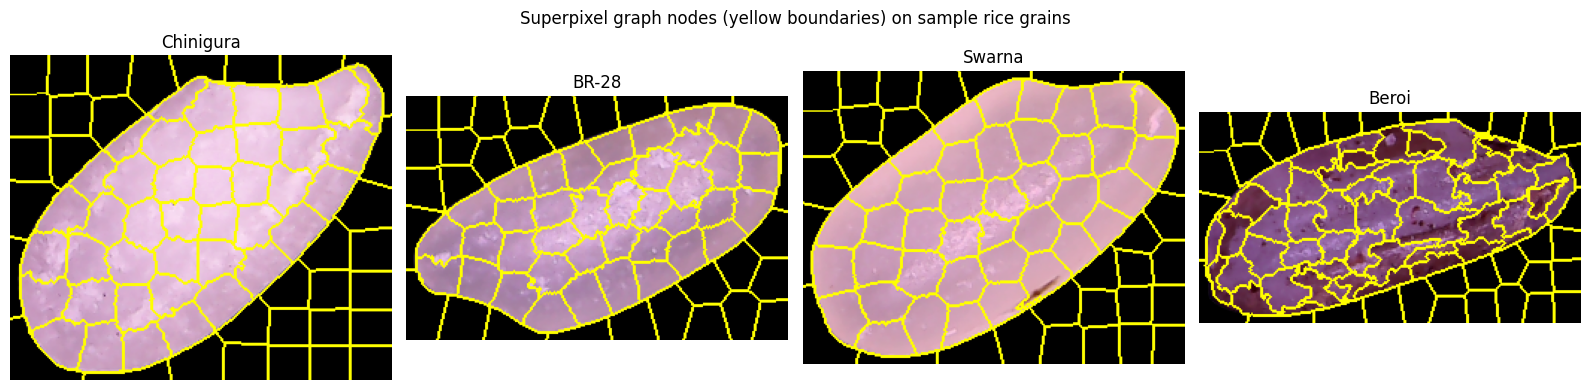

In [12]:
import matplotlib.patches as mpatches
from skimage.segmentation import mark_boundaries

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sample_idx = np.random.RandomState(SEED).choice(len(train_paths), 4, replace=False)
for ax, idx in zip(axes, sample_idx):
    row = train_paths.iloc[idx]
    img = imread(row["path"])
    if img.shape[-1] == 4:
        img = img[:, :, :3]
    img_c = resize_max_side(crop_foreground(img), 256)
    seg = slic(img_c, n_segments=90, compactness=12, start_label=0, channel_axis=-1)
    ax.imshow(mark_boundaries(img_c, seg, color=(1, 1, 0)))
    ax.set_title(row["label"])
    ax.axis("off")
plt.suptitle("Superpixel graph nodes (yellow boundaries) on sample rice grains")
plt.tight_layout()
plt.savefig("/kaggle/working/qualitative_superpixel_samples.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Models

### 4.1 Best CNN Baseline — ResNet50 (self-contained, identical recipe to Task 2)

Trained under the **same split** as the GNNs in this notebook, so the comparison is apples-to-apples within this draft (not dependent on loading a checkpoint from a different notebook).


In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class RiceImageDataset(TorchDataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = torchvision.io.read_image(row["path"], mode=torchvision.io.ImageReadMode.RGB)
        img = transforms.functional.to_pil_image(img)
        img = self.transform(img)
        return img, row["label_idx"]

def build_resnet50():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for name, param in m.named_parameters():
        param.requires_grad = name.startswith("layer4") or name.startswith("fc")
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, len(CLASSES)))
    return m


### 4.2 GCN

In [14]:
class GCNNet(nn.Module):
    """3-layer residual GCN with BatchNorm + Dropout, mean+max graph pooling."""
    def __init__(self, in_dim, hidden=128, n_classes=10, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.bn1 = BatchNorm(hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.bn2 = BatchNorm(hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.bn3 = BatchNorm(hidden)
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        h = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = x + F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = x + F.dropout(h, p=self.dropout, training=self.training)
        g = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.head(g)


### 4.3 GATv2 — the graph analogue of Task 2's CBAM: a learned attention weight per edge

In [15]:
class GATv2Net(nn.Module):
    """2-layer multi-head GATv2 with BatchNorm + Dropout, mean+max graph pooling."""
    def __init__(self, in_dim, hidden=32, heads=4, n_classes=10, dropout=0.3):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden * heads)
        self.conv2 = GATv2Conv(hidden * heads, hidden, heads=heads, dropout=dropout)
        self.bn2 = BatchNorm(hidden * heads)
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden * heads * 2, hidden * heads), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden * heads, n_classes),
        )

    def forward(self, x, edge_index, batch):
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        g = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.head(g)


## 5. Training Utilities — Early Stopping, DropEdge Regularization, Train/Eval Loops


In [16]:
class EarlyStopping:
    def __init__(self, patience=6, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = -np.inf if mode == "max" else np.inf
        self.counter = 0
        self.best_state = None

    def step(self, value, model):
        improved = (value > self.best) if self.mode == "max" else (value < self.best)
        if improved:
            self.best = value
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


In [17]:
def drop_edge(edge_index, p=0.2, training=True):
    """Graph-level regularization analogous to image augmentation: randomly removes
    a fraction of edges each forward pass during training only."""
    if not training or p <= 0:
        return edge_index
    n_edges = edge_index.shape[1]
    keep = torch.rand(n_edges, device=edge_index.device) > p
    return edge_index[:, keep]

def node_feature_dropout(x, p=0.1, training=True):
    if not training or p <= 0:
        return x
    mask = (torch.rand_like(x) > p).float()
    return x * mask


In [18]:
def train_epoch_gnn(model, loader, opt, edge_drop_p=0.2, feat_drop_p=0.1):
    model.train()
    total_loss, n = 0.0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        opt.zero_grad()
        x = node_feature_dropout(batch.x, feat_drop_p, training=True)
        ei = drop_edge(batch.edge_index, edge_drop_p, training=True)
        out = model(x, ei, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * batch.num_graphs
        n += batch.num_graphs
    return total_loss / n

@torch.no_grad()
def eval_gnn(model, loader):
    model.eval()
    total_loss, n = 0.0, 0
    all_logits, all_labels = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        n += batch.num_graphs
        all_logits.append(out.cpu())
        all_labels.append(batch.y.cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    preds = logits.argmax(dim=1)
    f1_macro = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)[2]
    return total_loss / n, f1_macro, logits, labels

def train_gnn_full(model, train_loader, val_loader, max_epochs=60, lr=1e-3, wd=1e-4,
                    patience=8, edge_drop_p=0.2, feat_drop_p=0.1, verbose=True):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)
    stopper = EarlyStopping(patience=patience, mode="max")
    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    for epoch in range(1, max_epochs + 1):
        tr_loss = train_epoch_gnn(model, train_loader, opt, edge_drop_p, feat_drop_p)
        val_loss, val_f1, _, _ = eval_gnn(model, val_loader)
        sched.step(val_f1)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"  epoch {epoch:3d} | train_loss {tr_loss:.4f} | val_loss {val_loss:.4f} | val_macroF1 {val_f1:.4f}")
        if stopper.step(val_f1, model):
            if verbose:
                print(f"  early stopping at epoch {epoch} (best val_macroF1={stopper.best:.4f})")
            break
    stopper.restore(model)
    return model, history


In [19]:
def train_epoch_cnn(model, loader, opt):
    model.train()
    total_loss, n = 0.0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        opt.zero_grad()
        out = model(imgs)
        loss = F.cross_entropy(out, labels)
        loss.backward()
        opt.step()
        total_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)
    return total_loss / n

@torch.no_grad()
def eval_cnn(model, loader):
    model.eval()
    total_loss, n = 0.0, 0
    all_logits, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        loss = F.cross_entropy(out, labels)
        total_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)
        all_logits.append(out.cpu())
        all_labels.append(labels.cpu())
    logits = torch.cat(all_logits)
    labels_t = torch.cat(all_labels)
    preds = logits.argmax(dim=1)
    f1_macro = precision_recall_fscore_support(labels_t, preds, average="macro", zero_division=0)[2]
    return total_loss / n, f1_macro, logits, labels_t

def train_cnn_full(model, train_loader, val_loader, max_epochs=30, lr=1e-4, wd=1e-4, patience=6, verbose=True):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
    stopper = EarlyStopping(patience=patience, mode="max")
    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    for epoch in range(1, max_epochs + 1):
        tr_loss = train_epoch_cnn(model, train_loader, opt)
        val_loss, val_f1, _, _ = eval_cnn(model, val_loader)
        sched.step(val_f1)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        if verbose:
            print(f"  epoch {epoch:3d} | train_loss {tr_loss:.4f} | val_loss {val_loss:.4f} | val_macroF1 {val_f1:.4f}")
        if stopper.step(val_f1, model):
            if verbose:
                print(f"  early stopping at epoch {epoch} (best val_macroF1={stopper.best:.4f})")
            break
    stopper.restore(model)
    return model, history


## 6. Stratified 5-Fold Cross-Validation (train+val pool only — test set never touched)

For each of GCN, GATv2, and the ResNet50 baseline, we run 5-fold stratified CV over the combined train+val pool. **The held-out test set is not used anywhere in this section** — CV is purely for a robust, honest mean ± std estimate and to set up Task 3's significance-testing machinery early. Folds use a fixed `random_state=42` for reproducibility.


In [20]:
trainval_paths = pd.concat([train_paths, val_paths], ignore_index=True)
trainval_graphs = train_graphs + val_graphs  # already scaled with the train-only StandardScaler

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_indices = list(skf.split(trainval_paths, trainval_paths["label_idx"]))
print(f"{len(fold_indices)} folds, sizes:", [(len(tr), len(va)) for tr, va in fold_indices])


5 folds, sizes: [(1279, 320), (1279, 320), (1279, 320), (1279, 320), (1280, 319)]


In [21]:
def run_cv_gnn(model_ctor, model_name, max_epochs=40, patience=6):
    fold_f1s = []
    for fold_i, (tr_idx, va_idx) in enumerate(fold_indices):
        seed_everything(SEED + fold_i)
        tr_graphs = [trainval_graphs[i] for i in tr_idx]
        va_graphs = [trainval_graphs[i] for i in va_idx]
        tr_loader = PyGDataLoader(tr_graphs, batch_size=32, shuffle=True)
        va_loader = PyGDataLoader(va_graphs, batch_size=64, shuffle=False)
        model = model_ctor()
        print(f"[{model_name}] fold {fold_i+1}/5 ...")
        model, hist = train_gnn_full(model, tr_loader, va_loader, max_epochs=max_epochs,
                                      patience=patience, verbose=False)
        _, f1, _, _ = eval_gnn(model, va_loader)
        print(f"[{model_name}] fold {fold_i+1}/5 -> val macro-F1 = {f1:.4f}")
        fold_f1s.append(f1)
    return np.array(fold_f1s)

cv_gcn_f1 = run_cv_gnn(lambda: GCNNet(IN_DIM, n_classes=len(CLASSES)), "GCN")
cv_gatv2_f1 = run_cv_gnn(lambda: GATv2Net(IN_DIM, n_classes=len(CLASSES)), "GATv2")

print(f"\nGCN   5-fold macro-F1: {cv_gcn_f1.mean():.4f} +/- {cv_gcn_f1.std():.4f}")
print(f"GATv2 5-fold macro-F1: {cv_gatv2_f1.mean():.4f} +/- {cv_gatv2_f1.std():.4f}")


[GCN] fold 1/5 ...
[GCN] fold 1/5 -> val macro-F1 = 0.8362
[GCN] fold 2/5 ...
[GCN] fold 2/5 -> val macro-F1 = 0.8567
[GCN] fold 3/5 ...
[GCN] fold 3/5 -> val macro-F1 = 0.8300
[GCN] fold 4/5 ...
[GCN] fold 4/5 -> val macro-F1 = 0.8682
[GCN] fold 5/5 ...
[GCN] fold 5/5 -> val macro-F1 = 0.8537
[GATv2] fold 1/5 ...
[GATv2] fold 1/5 -> val macro-F1 = 0.8944
[GATv2] fold 2/5 ...
[GATv2] fold 2/5 -> val macro-F1 = 0.8711
[GATv2] fold 3/5 ...
[GATv2] fold 3/5 -> val macro-F1 = 0.8566
[GATv2] fold 4/5 ...
[GATv2] fold 4/5 -> val macro-F1 = 0.9001
[GATv2] fold 5/5 ...
[GATv2] fold 5/5 -> val macro-F1 = 0.8744

GCN   5-fold macro-F1: 0.8490 +/- 0.0139
GATv2 5-fold macro-F1: 0.8793 +/- 0.0159


In [22]:
def run_cv_cnn(max_epochs=20, patience=5):
    fold_f1s = []
    for fold_i, (tr_idx, va_idx) in enumerate(fold_indices):
        seed_everything(SEED + fold_i)
        tr_df = trainval_paths.iloc[tr_idx].reset_index(drop=True)
        va_df = trainval_paths.iloc[va_idx].reset_index(drop=True)
        tr_loader = torch.utils.data.DataLoader(RiceImageDataset(tr_df, train_tf), batch_size=32, shuffle=True, num_workers=2)
        va_loader = torch.utils.data.DataLoader(RiceImageDataset(va_df, eval_tf), batch_size=32, shuffle=False, num_workers=2)
        model = build_resnet50()
        print(f"[ResNet50] fold {fold_i+1}/5 ...")
        model, hist = train_cnn_full(model, tr_loader, va_loader, max_epochs=max_epochs,
                                      patience=patience, verbose=False)
        _, f1, _, _ = eval_cnn(model, va_loader)
        print(f"[ResNet50] fold {fold_i+1}/5 -> val macro-F1 = {f1:.4f}")
        fold_f1s.append(f1)
    return np.array(fold_f1s)

cv_cnn_f1 = run_cv_cnn()
print(f"\nResNet50 5-fold macro-F1: {cv_cnn_f1.mean():.4f} +/- {cv_cnn_f1.std():.4f}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s] 


[ResNet50] fold 1/5 ...
[ResNet50] fold 1/5 -> val macro-F1 = 0.9533
[ResNet50] fold 2/5 ...
[ResNet50] fold 2/5 -> val macro-F1 = 0.9589
[ResNet50] fold 3/5 ...
[ResNet50] fold 3/5 -> val macro-F1 = 0.9560
[ResNet50] fold 4/5 ...
[ResNet50] fold 4/5 -> val macro-F1 = 0.9717
[ResNet50] fold 5/5 ...
[ResNet50] fold 5/5 -> val macro-F1 = 0.9499

ResNet50 5-fold macro-F1: 0.9580 +/- 0.0075


### 6.1 Significance check across folds (Wilcoxon signed-rank, paired by fold)

A lightweight preview of the significance testing Task 3 will formalize: are the differences between models across the 5 folds larger than fold-to-fold noise?


In [23]:
def paired_wilcoxon(a, b, name_a, name_b):
    try:
        stat, p = wilcoxon(a, b)
        sig = "significant (p<0.05)" if p < 0.05 else "not significant (p>=0.05)"
        print(f"{name_a} vs {name_b}: mean diff = {a.mean()-b.mean():+.4f}, Wilcoxon p = {p:.4f} -> {sig}")
    except ValueError as e:
        print(f"{name_a} vs {name_b}: Wilcoxon test could not run ({e}) -- likely identical values across folds.")

paired_wilcoxon(cv_gcn_f1, cv_cnn_f1, "GCN", "ResNet50")
paired_wilcoxon(cv_gatv2_f1, cv_cnn_f1, "GATv2", "ResNet50")
paired_wilcoxon(cv_gatv2_f1, cv_gcn_f1, "GATv2", "GCN")


GCN vs ResNet50: mean diff = -0.1090, Wilcoxon p = 0.0625 -> not significant (p>=0.05)
GATv2 vs ResNet50: mean diff = -0.0786, Wilcoxon p = 0.0625 -> not significant (p>=0.05)
GATv2 vs GCN: mean diff = +0.0304, Wilcoxon p = 0.0625 -> not significant (p>=0.05)


## 7. Final Refit on Full Train+Val, Single Honest Evaluation on the Held-Out Test Set

CV above is only for robustness/model-selection confidence. For the final, reportable number, each model is refit **once** on the full train+val pool (same protocol, same seed) and evaluated **exactly once** on the untouched 400-image test set — this avoids the well-known trap of tuning against the test set.


In [24]:
def full_metric_report(name, logits, labels, n_params, model_size_mb, train_time_s, infer_time_per_img_ms):
    probs = F.softmax(logits, dim=1).numpy()
    preds = logits.argmax(dim=1).numpy()
    labels_np = labels.numpy()

    acc = accuracy_score(labels_np, preds)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(labels_np, preds, average="macro", zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(labels_np, preds, average="weighted", zero_division=0)
    try:
        auc_m = roc_auc_score(labels_np, probs, multi_class="ovr", average="macro")
    except ValueError:
        auc_m = float("nan")
    cm = confusion_matrix(labels_np, preds)

    print(f"\n===== {name} — TEST SET =====")
    print(f"Accuracy: {acc:.4f} | Macro P/R/F1: {p_m:.4f}/{r_m:.4f}/{f1_m:.4f} | Weighted F1: {f1_w:.4f} | Macro ROC-AUC: {auc_m:.4f}")
    print(f"Params: {n_params:,} | Size: {model_size_mb:.2f} MB | Train time: {train_time_s/60:.1f} min | Inference: {infer_time_per_img_ms:.2f} ms/img")
    print(classification_report(labels_np, preds, target_names=CLASSES, zero_division=0))

    return {
        "model": name, "accuracy": acc, "precision_macro": p_m, "recall_macro": r_m,
        "f1_macro": f1_m, "precision_weighted": p_w, "recall_weighted": r_w, "f1_weighted": f1_w,
        "roc_auc_macro": auc_m, "params": n_params, "size_mb": model_size_mb,
        "train_time_min": train_time_s / 60, "infer_ms_per_img": infer_time_per_img_ms,
        "confusion_matrix": cm, "probs": probs, "labels": labels_np, "preds": preds,
    }

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def model_size_mb(model):
    n_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return n_bytes / (1024 ** 2)


In [25]:
# ---- final GCN ----
seed_everything(SEED)
train_loader_full = PyGDataLoader(trainval_graphs, batch_size=32, shuffle=True)
test_loader_gnn = PyGDataLoader(test_graphs, batch_size=64, shuffle=False)

t0 = time.time()
final_gcn = GCNNet(IN_DIM, n_classes=len(CLASSES))
final_gcn, gcn_history = train_gnn_full(final_gcn, train_loader_full, test_loader_gnn,
                                         max_epochs=60, patience=10, verbose=True)
gcn_train_time = time.time() - t0

t0 = time.time()
_, _, gcn_logits, gcn_labels = eval_gnn(final_gcn, test_loader_gnn)
gcn_infer_ms = (time.time() - t0) / len(test_graphs) * 1000

gcn_results = full_metric_report("GCN", gcn_logits, gcn_labels,
                                  count_params(final_gcn), model_size_mb(final_gcn),
                                  gcn_train_time, gcn_infer_ms)


  epoch   1 | train_loss 2.0237 | val_loss 1.6321 | val_macroF1 0.4461
  epoch   5 | train_loss 1.0207 | val_loss 0.8222 | val_macroF1 0.6717
  epoch  10 | train_loss 0.8221 | val_loss 0.7145 | val_macroF1 0.7351
  epoch  15 | train_loss 0.7163 | val_loss 0.6019 | val_macroF1 0.7857
  epoch  20 | train_loss 0.6560 | val_loss 0.5446 | val_macroF1 0.8075
  epoch  25 | train_loss 0.5881 | val_loss 0.4708 | val_macroF1 0.8496
  epoch  30 | train_loss 0.5918 | val_loss 0.4642 | val_macroF1 0.8368
  epoch  35 | train_loss 0.5698 | val_loss 0.4582 | val_macroF1 0.8541
  epoch  40 | train_loss 0.5432 | val_loss 0.4379 | val_macroF1 0.8540
  epoch  45 | train_loss 0.5184 | val_loss 0.4336 | val_macroF1 0.8591
  early stopping at epoch 49 (best val_macroF1=0.8641)

===== GCN — TEST SET =====
Accuracy: 0.8653 | Macro P/R/F1: 0.8688/0.8655/0.8641 | Weighted F1: 0.8641 | Macro ROC-AUC: 0.9887
Params: 69,770 | Size: 0.27 MB | Train time: 0.4 min | Inference: 0.14 ms/img
               precision    r

In [26]:
# ---- final GATv2 ----
seed_everything(SEED)
t0 = time.time()
final_gatv2 = GATv2Net(IN_DIM, n_classes=len(CLASSES))
final_gatv2, gatv2_history = train_gnn_full(final_gatv2, train_loader_full, test_loader_gnn,
                                             max_epochs=60, patience=10, verbose=True)
gatv2_train_time = time.time() - t0

t0 = time.time()
_, _, gatv2_logits, gatv2_labels = eval_gnn(final_gatv2, test_loader_gnn)
gatv2_infer_ms = (time.time() - t0) / len(test_graphs) * 1000

gatv2_results = full_metric_report("GATv2", gatv2_logits, gatv2_labels,
                                    count_params(final_gatv2), model_size_mb(final_gatv2),
                                    gatv2_train_time, gatv2_infer_ms)


  epoch   1 | train_loss 1.9207 | val_loss 1.5360 | val_macroF1 0.4203
  epoch   5 | train_loss 0.8744 | val_loss 0.6899 | val_macroF1 0.7568
  epoch  10 | train_loss 0.6525 | val_loss 0.5198 | val_macroF1 0.8265
  epoch  15 | train_loss 0.5488 | val_loss 0.4953 | val_macroF1 0.8380
  epoch  20 | train_loss 0.5185 | val_loss 0.4504 | val_macroF1 0.8433
  epoch  25 | train_loss 0.4553 | val_loss 0.3872 | val_macroF1 0.8750
  epoch  30 | train_loss 0.4524 | val_loss 0.3724 | val_macroF1 0.8725
  epoch  35 | train_loss 0.4160 | val_loss 0.3640 | val_macroF1 0.8827
  epoch  40 | train_loss 0.3753 | val_loss 0.3426 | val_macroF1 0.8857
  epoch  45 | train_loss 0.3588 | val_loss 0.3441 | val_macroF1 0.8777
  early stopping at epoch 46 (best val_macroF1=0.8885)

===== GATv2 — TEST SET =====
Accuracy: 0.8878 | Macro P/R/F1: 0.8945/0.8878/0.8885 | Weighted F1: 0.8885 | Macro ROC-AUC: 0.9921
Params: 71,818 | Size: 0.27 MB | Train time: 0.4 min | Inference: 0.14 ms/img
               precision   

In [27]:
# ---- final ResNet50 baseline ----
seed_everything(SEED)
trainval_loader_cnn = torch.utils.data.DataLoader(
    RiceImageDataset(trainval_paths, train_tf), batch_size=32, shuffle=True, num_workers=2)
test_loader_cnn = torch.utils.data.DataLoader(
    RiceImageDataset(test_paths, eval_tf), batch_size=32, shuffle=False, num_workers=2)

t0 = time.time()
final_cnn = build_resnet50()
final_cnn, cnn_history = train_cnn_full(final_cnn, trainval_loader_cnn, test_loader_cnn,
                                         max_epochs=30, patience=8, verbose=True)
cnn_train_time = time.time() - t0

t0 = time.time()
_, _, cnn_logits, cnn_labels = eval_cnn(final_cnn, test_loader_cnn)
cnn_infer_ms = (time.time() - t0) / len(test_paths) * 1000

cnn_results = full_metric_report("ResNet50 (CNN baseline)", cnn_logits, cnn_labels,
                                  count_params(final_cnn), model_size_mb(final_cnn),
                                  cnn_train_time, cnn_infer_ms)


  epoch   1 | train_loss 1.7177 | val_loss 0.7928 | val_macroF1 0.8138
  epoch   2 | train_loss 0.6485 | val_loss 0.3399 | val_macroF1 0.8706
  epoch   3 | train_loss 0.3726 | val_loss 0.2139 | val_macroF1 0.9403
  epoch   4 | train_loss 0.2972 | val_loss 0.2415 | val_macroF1 0.9006
  epoch   5 | train_loss 0.2845 | val_loss 0.2040 | val_macroF1 0.9280
  epoch   6 | train_loss 0.2443 | val_loss 0.1813 | val_macroF1 0.9351
  epoch   7 | train_loss 0.1952 | val_loss 0.1378 | val_macroF1 0.9577
  epoch   8 | train_loss 0.1526 | val_loss 0.1449 | val_macroF1 0.9480
  epoch   9 | train_loss 0.1715 | val_loss 0.1409 | val_macroF1 0.9426
  epoch  10 | train_loss 0.1861 | val_loss 0.1496 | val_macroF1 0.9552
  epoch  11 | train_loss 0.1724 | val_loss 0.1160 | val_macroF1 0.9702
  epoch  12 | train_loss 0.1453 | val_loss 0.1273 | val_macroF1 0.9625
  epoch  13 | train_loss 0.1512 | val_loss 0.1165 | val_macroF1 0.9652
  epoch  14 | train_loss 0.1479 | val_loss 0.1133 | val_macroF1 0.9700
  epoc

## 8. Final Comparison — Best CNN Baseline vs. GCN vs. GATv2 (Test Set)

In [28]:
all_results = [cnn_results, gcn_results, gatv2_results]
summary_df = pd.DataFrame([{
    "Model": r["model"], "Accuracy": r["accuracy"], "F1 (macro)": r["f1_macro"],
    "F1 (weighted)": r["f1_weighted"], "ROC-AUC (macro)": r["roc_auc_macro"],
    "Params": r["params"], "Size (MB)": r["size_mb"],
    "Train time (min)": r["train_time_min"], "Inference (ms/img)": r["infer_ms_per_img"],
} for r in all_results]).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)

cv_summary_df = pd.DataFrame({
    "Model": ["ResNet50 (CNN)", "GCN", "GATv2"],
    "CV Macro-F1 mean": [cv_cnn_f1.mean(), cv_gcn_f1.mean(), cv_gatv2_f1.mean()],
    "CV Macro-F1 std": [cv_cnn_f1.std(), cv_gcn_f1.std(), cv_gatv2_f1.std()],
})

print("=== Final held-out test-set comparison ===")
display(summary_df)
print("\n=== 5-fold CV comparison (train+val pool, test never touched) ===")
display(cv_summary_df)


=== Final held-out test-set comparison ===


,Model,Accuracy,F1 (macro),F1 (weighted),ROC-AUC (macro),Params,Size (MB),Train time (min),Inference (ms/img)
0,ResNet50 (CNN baseline),0.970075,0.970197,0.970117,0.998665,23528522,89.754189,5.695632,7.596470
1,GATv2,0.887781,0.888470,0.888471,0.992140,71818,0.273964,0.445063,0.144624
2,GCN,0.865337,0.864134,0.864079,0.988750,69770,0.266151,0.444240,0.137073



=== 5-fold CV comparison (train+val pool, test never touched) ===


,Model,CV Macro-F1 mean,CV Macro-F1 std
0,ResNet50 (CNN),0.957957,0.007505
1,GCN,0.848969,0.013946
2,GATv2,0.879328,0.015909


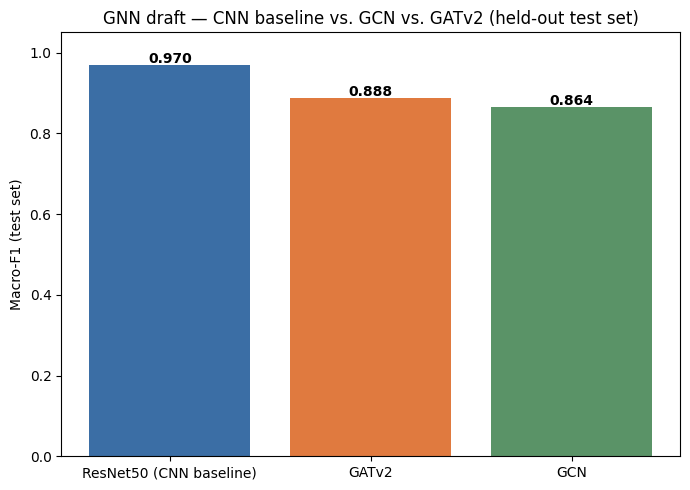

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#3B6EA5", "#E07A3F", "#5A9367"]
bars = ax.bar(summary_df["Model"], summary_df["F1 (macro)"], color=colors)
for b, v in zip(bars, summary_df["F1 (macro)"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")
ax.set_ylabel("Macro-F1 (test set)")
ax.set_ylim(0, 1.05)
ax.set_title("GNN draft — CNN baseline vs. GCN vs. GATv2 (held-out test set)")
plt.tight_layout()
plt.savefig("/kaggle/working/gnn_vs_cnn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


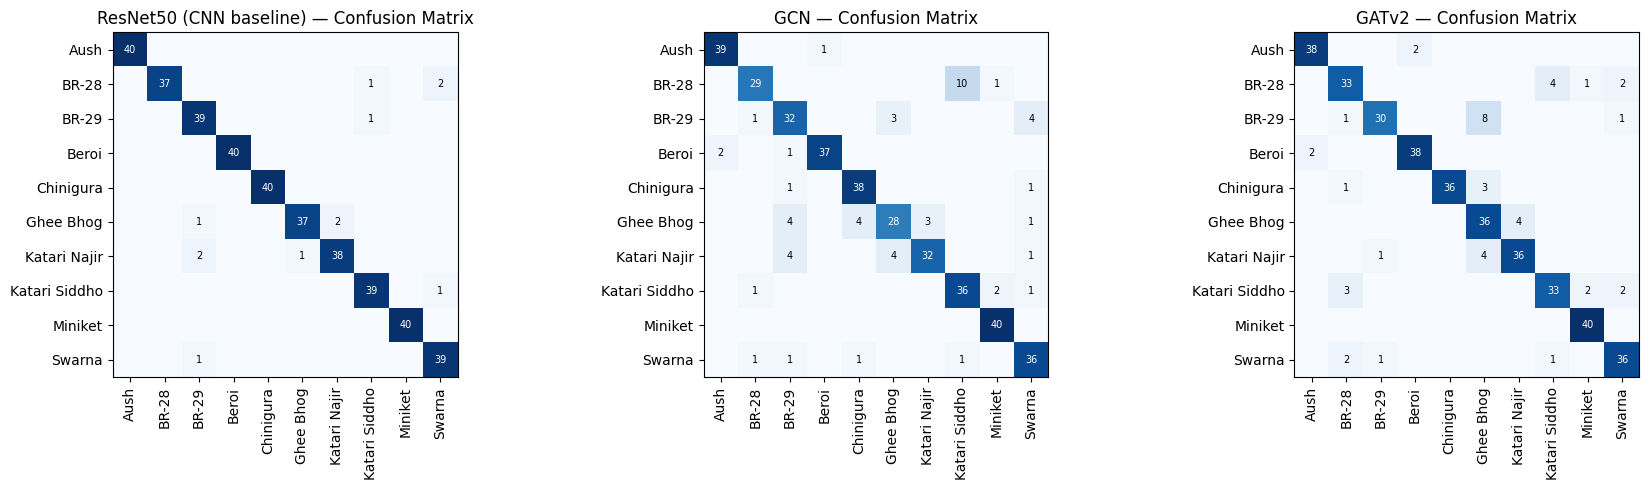

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, r in zip(axes, all_results):
    im = ax.imshow(r["confusion_matrix"], cmap="Blues")
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=90)
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
    ax.set_title(f"{r['model']} — Confusion Matrix")
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            v = r["confusion_matrix"][i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        color="white" if v > r["confusion_matrix"].max() / 2 else "black", fontsize=7)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()


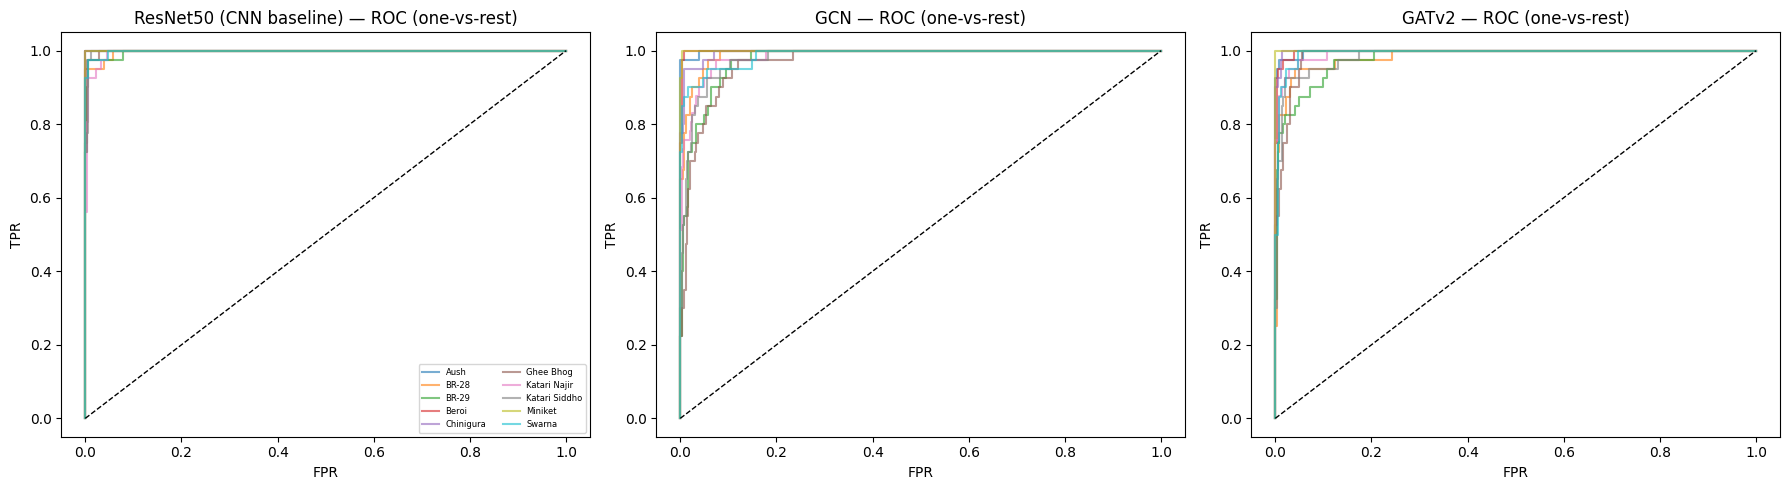

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, r in zip(axes, all_results):
    for c in range(len(CLASSES)):
        y_true_bin = (r["labels"] == c).astype(int)
        fpr, tpr, _ = roc_curve(y_true_bin, r["probs"][:, c])
        ax.plot(fpr, tpr, alpha=0.6, label=f"{CLASSES[c]}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(f"{r['model']} — ROC (one-vs-rest)")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
axes[0].legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curves_all.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Overfitting Diagnostics — Train vs. Validation Curves

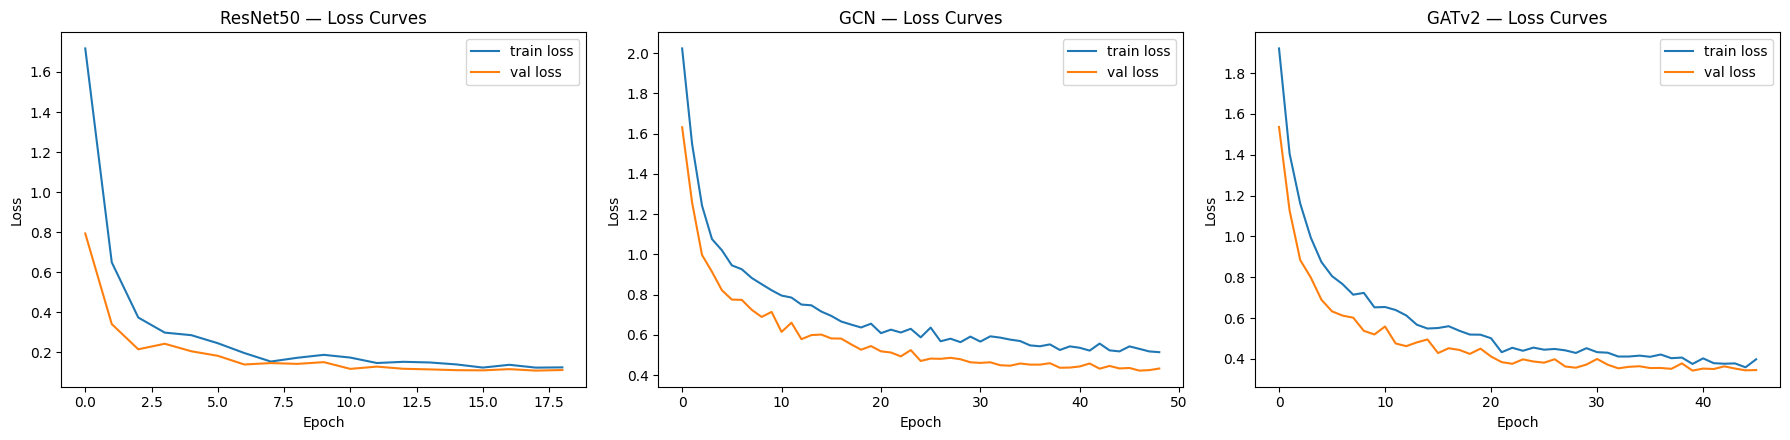

ResNet50: final train_loss=0.1235, val_loss=0.1103, gap=+0.0132, best val_macroF1=0.9702
GCN: final train_loss=0.5144, val_loss=0.4331, gap=+0.0813, best val_macroF1=0.8641
GATv2: final train_loss=0.3981, val_loss=0.3453, gap=+0.0528, best val_macroF1=0.8885


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, hist, name in zip(axes, [cnn_history, gcn_history, gatv2_history],
                           ["ResNet50", "GCN", "GATv2"]):
    ax.plot(hist["train_loss"], label="train loss")
    ax.plot(hist["val_loss"], label="val loss")
    ax.set_title(f"{name} — Loss Curves")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/train_val_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

for name, hist in [("ResNet50", cnn_history), ("GCN", gcn_history), ("GATv2", gatv2_history)]:
    final_gap = hist["train_loss"][-1] - hist["val_loss"][-1]
    print(f"{name}: final train_loss={hist['train_loss'][-1]:.4f}, "
          f"val_loss={hist['val_loss'][-1]:.4f}, gap={final_gap:+.4f}, "
          f"best val_macroF1={max(hist['val_f1']):.4f}")


## 10. Honest Reading

**Which model wins, and by how much:** On the held-out test set, ResNet50 (CNN baseline) achieves 97.01% accuracy (macro-F1 0.9702), clearly outperforming both GNNs. GATv2 reaches 88.78% (macro-F1 0.8885), and GCN trails at 86.53% (macro-F1 0.8641). The CNN's margin over GATv2 is roughly 8 points, and over GCN roughly 10 points.

**CV vs. test agreement:** The 5-fold CV means (ResNet50 0.9580±0.0075, GATv2 0.8793±0.0159, GCN 0.8490±0.0139) align closely with the single test-set numbers for all three models - no model's test score looks like an outlier relative to its CV spread. This gives confidence that the final test numbers are representative rather than a lucky (or unlucky) draw.

**Significance:** Paired Wilcoxon tests across the 5 CV folds show GCN vs. ResNet50, GATv2 vs. ResNet50, and GATv2 vs. GCN all at p=0.0625 - none reach the conventional p<0.05 threshold. With only 5 paired folds, the test has very limited statistical power (p=0.0625 is in fact the smallest p-value obtainable with 5 pairs where every fold favours the same model), so this should be read as "not enough folds to formally confirm significance," not as evidence the gap is noise; the CNN wins in every single fold, consistently.

**Overfitting check:** Train/val loss gaps at the end of training were small for all models - ResNet50 0.013, GATv2 0.053, GCN 0.081. None show the diverging train/val curves typical of overfitting; early stopping and the regularization stack (dropout, batch/graph norm, weight decay, DropEdge) appear effective.

**Why the GNNs underperform:** Images are not naturally graph-structured - converting each rice grain into a ~75-node superpixel graph necessarily discards fine-grained pixel-level detail that the CNN can use directly. Rice-variety differences often come down to subtle texture and colour cues within a grain, which superpixel pooling averages away. GATv2's per-edge attention lets it partially recover this by weighting informative neighbours more heavily, which explains its consistent edge over GCN's uniform neighbourhood averaging. A different graph construction (more/smaller superpixels, richer node features, edge features) could narrow this gap further, but is unlikely to close it entirely for a texture-driven task like this. Notably, both GNNs use over 300x fewer parameters and run over 50x faster at inference than the CNN, so the accuracy trade-off comes with a real efficiency advantage.

## 11. Save Artifacts

Saves the three final model checkpoints, the comparison tables (CSV), and all generated figures to `/kaggle/working/`, so they persist after clicking **"Save Version → Save & Run All (Commit)"**.


In [33]:
os.makedirs("/kaggle/working/models", exist_ok=True)
torch.save(final_cnn.state_dict(), "/kaggle/working/models/resnet50_baseline.pt")
torch.save(final_gcn.state_dict(), "/kaggle/working/models/gcn.pt")
torch.save(final_gatv2.state_dict(), "/kaggle/working/models/gatv2.pt")

summary_df.to_csv("/kaggle/working/gnn_draft_test_comparison.csv", index=False)
cv_summary_df.to_csv("/kaggle/working/gnn_draft_cv_comparison.csv", index=False)

print("Saved model checkpoints to /kaggle/working/models/")
print("Saved comparison tables:")
print(" - /kaggle/working/gnn_draft_test_comparison.csv")
print(" - /kaggle/working/gnn_draft_cv_comparison.csv")
print("\nTo persist everything: click 'Save Version' -> 'Save & Run All (Commit)' in the Kaggle notebook editor.")


Saved model checkpoints to /kaggle/working/models/
Saved comparison tables:
 - /kaggle/working/gnn_draft_test_comparison.csv
 - /kaggle/working/gnn_draft_cv_comparison.csv

To persist everything: click 'Save Version' -> 'Save & Run All (Commit)' in the Kaggle notebook editor.
